

---

```
CISC 3440: Machine Learning
P2 (35 Points)
Due: Nov 24th, 11:59 pm
```
---
**Submission Instructions**


* You are expected to complete this project on your own (not with a partner).
* Please refer to the syllabus for the late submission policy.
* You must submit your assignment via Blackboard.
* Your code should work without errors; code that fails will not be graded.


We will work with the Kaggle Dataset (https://www.kaggle.com/datasets/ivansher/nasa-nearest-earth-objects-1910-2024) for this project. The dataset involves predicting if a nearest object to earth is Hazardous.

The project will involve two parts:
1. In the first part you will implement the Perceptron Algorithm and Train the model using the data
2. In the second part you will use Linear Regression to build a model for the same


You are provided with one file train.csv. You are also provided with some started code to read files and process them. You will use Pandas to load and process the feature. ***Please work with the Pandas and Regression tutorials before you start with the project.***

**Data Features:** Each line in the file has the following Features

| **Column Name**             | **Description**                                                                 |
|-----------------------------|---------------------------------------------------------------------------------|
| `absolute_magnitude`        | The absolute magnitude of the object, indicating its brightness.               |
| `estimated_diameter_min`    | The minimum estimated diameter of the object, likely in kilometers or meters.  |
| `estimated_diameter_max`    | The maximum estimated diameter of the object, likely in kilometers or meters.  |
| `relative_velocity`         | The speed at which the object is moving relative to Earth, typically in m/s or km/h. |
| `miss_distance`             | The minimum distance by which the object is expected to miss Earth, possibly in kilometers. |
| `is_hazardous`              | A boolean indicator (TRUE/FALSE) of whether the object is classified as potentially hazardous to Earth. |


#Part-1 Perceptron

For the first part you will implement the Perceptron Algorithm, which you will use to train the data. You can use the implementation of the algorithm provided in your slides, **but be prepared to explain the algorithm to me in person if asked**.

**[5 points] Task-1: Perceptron Algorithm**

Complete the function definition below for training the Perceptron algorithm, the algorithm will take the following parameters as input:
- training_samples of shape (N,D) where N is the number of samples and D is the number of features
- training_labels of shape (N,1) where N is the number of samples
- iterations the number of times to iterate over the entire dataset

The function will return two lists:

- *weight_values* : A list of weight vectors obtained at the end of each iteration, this list will contain elements equivalent to the number of iterations

- *bias_values* : A list of bias values obtained at the end of each iteration, this list will also contain elements equivalent to the number of iterations

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import random

def perceptron_algorithm(training_samples,training_labels,iterations):
  """
  Trains a Perceptron model on the provided training samples and labels for a specified number of iterations.

  Parameters
  ----------
  training_samples : numpy.ndarray
      A 2D array of shape (num_samples, num_features), where each row represents a training sample
      and each column represents a feature.

  training_labels : numpy.ndarray
      A 1D array of shape (num_samples,), where each element is the label for the corresponding
      training sample in `training_samples`.

  iterations : int
      The number of epochs (full passes through the training data) to perform.

  Returns
  -------
  weight_values : list of numpy.ndarray
      A list of numpy arrays, each representing the weights after each epoch.

  bias_values : list of float
      A list of bias values after each epoch.

  Notes
  -----
  - You should initialize the weight and bias values randomly.


  Example
  -------
  >>> import numpy as np
  >>> training_samples = np.array([[1, 2], [2, 3], [-1, -1]])
  >>> training_labels = np.array([1, 1, -1])
  >>> weight_values, bias_values = perceptron_algorithm(training_samples, training_labels, iterations=10)

  """
  weight_values=[]
  bias_values=[]

  # Get the number of columns in the features array to know how many columns
  # to initialize the weight values
  feature_dimension = training_samples.shape[-1]

  # Initialize random weight and bias to start and add them to our lists
  weight = np.random.rand(feature_dimension)
  bias = np.random.rand(1)

  weight_values.append(weight)
  bias_values.append(bias)

  print("The current weight: {} and bias: {}".format(weight_values, bias_values))

  for i in range(iterations):
    for train_feature, train_label in zip(training_samples, training_labels):
      # Our activation value is the dot product of the features and the weight + the bias
      activation = np.dot(train_feature, weight) + bias

      y = 1 if train_label else -1

      # If our prediction was incorrect, update the weight and bias
      if y * activation <= 0:
        weight += y * train_feature
        bias += y


      # Append new weight values to list
    weight_values.append(weight.copy())
    bias_values.append(bias.copy())
  # print(weight_values[:5], bias_values[:5])
  return weight_values, bias_values

**[2 Points] Task-2: Predictions**

Complete the function definition below. The function should take three parameters:
- test_sample: A single test sample
- w: Weight vector
- b: bias value

and return the prediction +1 or -1 depending on the acitivation value

In [ ]:
def perceptron_predict(test_sample,w,b):
  """
    Predicts the class label for a given test sample using the Perceptron model.


    Parameters
    ----------
    test_sample : numpy.ndarray
        A 1D array representing the feature values of the test sample.

    w : numpy.ndarray
        A 1D array representing the weights learned by the Perceptron algorithm.

    b : float
        The bias term learned by the Perceptron algorithm.

    Returns
    -------
    int
        The predicted class label for the test sample: +1 if the sample is classified as positive,
        or -1 if classified as negative.

    Example
    -------
    >>> import numpy as np
    >>> test_sample = np.array([2, 3])
    >>> w = np.array([1, 0.5])
    >>> b = -1
    >>> perceptron_predict(test_sample, w, b)
    1
  """
  #FILL IN
  activation = np.dot(test_sample, w) + b

  return True if activation > 0 else False


###Data Loading and Preprocessing

You will use Pandas following the provided tutorials for Linear Regresssion to Load the data and process it. The project is exploratry and you are given freedom on how to process different features and how to handle missing data.

We will first load the data into Pandas and obtain relevant information.

In [ ]:
import pandas as pd

trainData=pd.read_csv("/content/train.csv")


**[4 Points] Task-3: Cleaning and Preprocessing**
Answer the following questions based on the results of info():
1. Are all the feature columns numeric?

2. Does any of the feature column contain missing values?

3. Can the label format be directly used to train the Perceptron algorithm?


Based on your answer to the above questions, in the code below you will do the following:

- If you found missing values, handle them. Use the tutorial to guide you on this.

- If the label format does not allow for direct training, you can change that. ***Hint: You will find the replace method in pandas useful**

- Split the features and labels into separate dataFrames. You can refer to tutorial on how to do this.

- Store the features data frame in the variable name *features* and labels in the variable name *labels*

- You might find it useful to standardize your features, refer to the Regression tutorial for this. The standardize features should still be stored in the variable name *features*.


Are all the feature columns numeric?
  - Yes all feature columns are type float64, which is numeric.

Does any of the feature column contain missing values?
  - No feature columns contain missing values.

Can the label format be directly used to train the Perceptron algorithm?
  - No it cannot, True evaluates to 1 and False evaluates to 0 but perceptron relies on False being equal to -1.

In [ ]:
features=None
labels=None

features = trainData.iloc[:, 0:5].to_numpy()
labels = trainData["is_hazardous"].to_numpy()

# I had a stray NaN at the end of my arrays
features = features[:-1]
labels = labels[:-1]


**[1 point] Task-4: Training and validation sets**

The next task is to create Training and Validation sets. For this you can use the *train_test_split()* method. Retain 90% of the data for training and 10% for testing.

The perceptron algorithm will take numpy arrays as input so you might want to convert your split data into numpy arrays using if the resulting arrays after the split are not numpy arrays.

> df.to_numpy()

where df is your data frame.

By the end of this, you should have four variables :

- train_features_numpy - Numpy array of dimension NxD where N is the number of    samples
- train_labels_numpy - Numpy array of dimension Nx1
- val_features_numpy - Numpy array of dimension MxD where M is the number of samples
- val_labels_numpy - Numpy array of dimension Mx1

In [ ]:
# 90% train, 10% validate
train_percent = int(len(features) * .9)
test_percent = int(len(features) * .1)
train_features_numpy, val_features_numpy = features[1:train_percent], features[train_percent:]
train_labels_numpy, val_labels_numpy = labels[1:train_percent], labels[train_percent:]


[[2.68900000e+01 1.11315330e-02 2.48908640e-02 7.37539643e+04
  3.55669671e+07]
 [2.63000000e+01 1.46067960e-02 3.26617900e-02 7.30353841e+04
  2.60630940e+06]
 [2.37000000e+01 4.83676490e-02 1.08153351e-01 3.25838170e+04
  2.29604677e+07]
 ...
 [2.64000000e+01 1.39493820e-02 3.11917670e-02 4.40567621e+04
  6.60932840e+06]
 [2.15000000e+01 1.33215567e-01 2.97879063e-01 6.32357911e+04
  4.67552810e+07]
 [2.14000000e+01 1.39493823e-01 3.11917671e-01 1.02204614e+05
  1.07454925e+07]]
[False False False ... False  True False]


**[2 points] Task-5: Training and validation**

You will train the model for 50-100 iterations, you are free to chose the number of iterations. Once trained you will use the returned weights and bias values to make predictions on the validation data and compute accuracy and F1-score for the weights and bias values from every iteration.

For computing accuracy and f1_score you can use sklearn library. Please refer to the official documentation.

- Computing accuracy using sklearn - refer [here](https://scikit-learn.org/1.5/modules/generated/sklearn.metrics.accuracy_score.html#sklearn.metrics.accuracy_score)

- Computing F1-score using sklearn - refere [here](https://scikit-learn.org/1.5/modules/generated/sklearn.metrics.f1_score.html#sklearn.metrics.f1_score)

The accuracy value should be stored in the variable name *accuracy_over_iterations* and F1-score in the variable name *f1_score_over_iterations*. These values will be used to generate plot which for now uses randomly generate accuracy and F1-scores for 100 iterations.

In [ ]:
iterations=50 # Set value
weight_values, bias_values=perceptron_algorithm(train_features_numpy, train_labels_numpy, iterations)

The current weight: [array([0.06151336, 0.29005679, 0.89459908, 0.19904365, 0.05016262])] and bias: [array([0.18998893])]


[False False False ... False  True False] [False, False, False, False, False, False, False, False, False, False, False, False, True, False, False, False, False, False, False, False, False, False, False, False, False, False, False, True, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, True, False, True, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, True, False, False, False, False, False, False, False, False, False, False, False, False, True, False, Fals

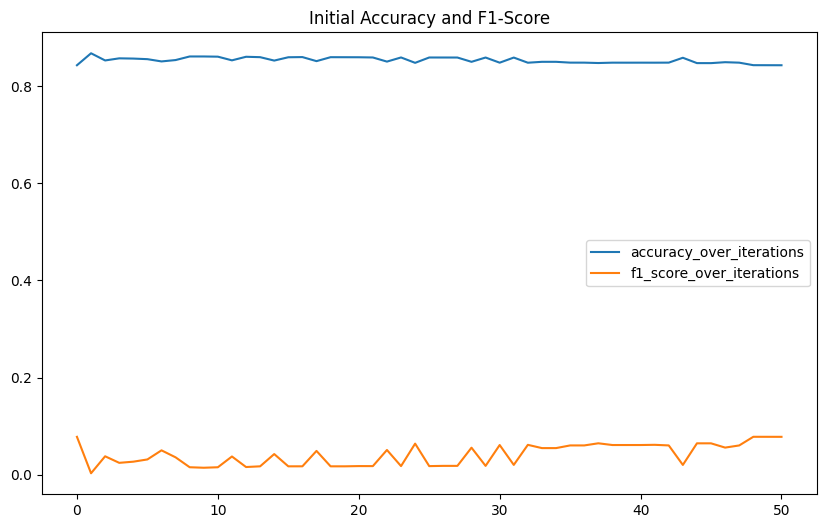

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import f1_score,accuracy_score
#FILL IN
y_true = val_labels_numpy
y_pred = []
accuracy_over_iterations=[]
f1_score_over_iterations=[]

for weight, bias in zip(weight_values, bias_values):
  for val_feature in val_features_numpy:
    pred = perceptron_predict(val_feature, weight, bias)
    y_pred.append(pred)
  accuracy_over_iterations.append(accuracy_score(y_true, y_pred))  # Calculate accuracy for current predictions
  f1_score_over_iterations.append(f1_score(y_true, y_pred))
  y_pred = []


y_pred = np.array(y_pred)
plt.figure(figsize=(10, 6))
plt.plot(accuracy_over_iterations,label='accuracy_over_iterations')
plt.plot(f1_score_over_iterations,label='f1_score_over_iterations')
plt.title("Initial Accuracy and F1-Score")
plt.legend()
plt.show()

**[1 Point] Task-6:** Based on the plots generated above answer the following questions:

4. Is there a difference in accuracy and F1-score values generated over different iterations?

5. What is possible reason behind the observed difference between accuracy and F1-score if any?

**[6 Points] Task-7: Balancing the Dataset**

The distribution of +1 and -1 samples are imbalanced in the dataset. As we saw in Lecture 5, there are different ways to address it

- Undersample
- Oversample

The code below shows how to undersample it and stores the resulting data into the variable *df_balanced*. You will generate df_balanced to generate new features and labels and repeat the training process. If you want you can also try to oversample and understand its impact on training.




In [ ]:
majority_class = trainData[trainData['is_hazardous'] == False]
minority_class = trainData[trainData['is_hazardous'] == True]
majority_downsampled = majority_class.sample(n=len(minority_class), random_state=42)
df_balanced = pd.concat([majority_downsampled, minority_class])
df_balanced = df_balanced.sample(frac=1, random_state=42).reset_index(drop=True)
df_balanced.info()
features=None
labels=None
features = df_balanced.iloc[:, 0:5].to_numpy()
labels = df_balanced["is_hazardous"].to_numpy()

# 90% train, 10% validate
train_percent = int(len(features) * .9)
test_percent = int(len(features) * .1)

train_features_numpy, val_features_numpy = features[1:train_percent], features[train_percent:]
train_labels_numpy, val_labels_numpy = labels[1:train_percent], labels[train_percent:]


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 68992 entries, 0 to 68991
Data columns (total 6 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   absolute_magnitude      68990 non-null  float64
 1   estimated_diameter_min  68990 non-null  float64
 2   estimated_diameter_max  68990 non-null  float64
 3   relative_velocity       68992 non-null  float64
 4   miss_distance           68992 non-null  float64
 5   is_hazardous            68992 non-null  bool   
dtypes: bool(1), float64(5)
memory usage: 2.7 MB


In [ ]:
iterations=50
weight_values, bias_values=perceptron_algorithm(train_features_numpy, train_labels_numpy, iterations)

The current weight: [array([0.65526947, 0.86462068, 0.65417243, 0.23307603, 0.18965403])] and bias: [array([0.75022961])]


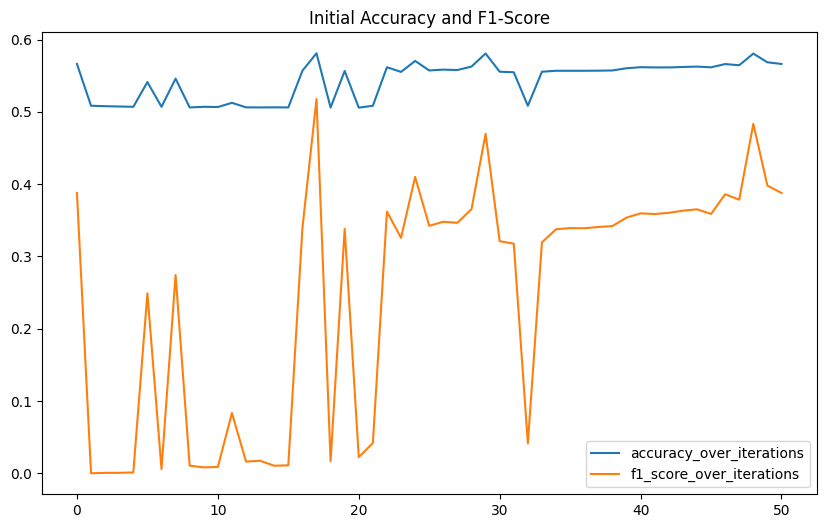

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import f1_score,accuracy_score
#FILL IN
y_true = val_labels_numpy
y_pred = []
accuracy_over_iterations=[]
f1_score_over_iterations=[]

for weight, bias in zip(weight_values, bias_values):
  for val_feature in val_features_numpy:
    pred = perceptron_predict(val_feature, weight, bias)
    y_pred.append(pred)
  accuracy_over_iterations.append(accuracy_score(y_true, y_pred))  # Calculate accuracy for current predictions
  f1_score_over_iterations.append(f1_score(y_true, y_pred))
  y_pred = []


y_pred = np.array(y_pred)
plt.figure(figsize=(10, 6))
plt.plot(accuracy_over_iterations,label='accuracy_over_iterations')
plt.plot(f1_score_over_iterations,label='f1_score_over_iterations')
plt.title("Initial Accuracy and F1-Score")
plt.legend()
plt.show()

**[2 points] Task-8**

5) Is there a difference between the plots generated before balancing and after balancing?

You will now pick an iteration based on the above plot. The weight values corresponding to that will be used to evaluate your trained model on test set.

In [ ]:
import pickle
chosen_iteration=17

if chosen_iteration is not None:
  weight=weight_values[chosen_iteration]
  bias=bias_values[chosen_iteration]
  model=[weight,bias]
  with open('perceptron_model.pkl', 'wb') as file:
    pickle.dump(model, file)

##Part-II Linear Regression

**[12 points] Task-9:**

For this task, you will use the same balanced dataset df_balanced that you previously created and fit a linear regression model. You can closely follow the Linear Regression Tutorial for this. You have to make the following decisions:
- Should you increase the number of features using different basis functions?
- Should you use normal least squares or ridge regression? If you want to try ridget regression what *alpha* values should you try?

Once you have made the decisions, you can fit a model. You will use the same 90-10 split for training and validation. For predictions, as regression will output continous floating point values, we will interepret the class based on the following condition:
  > If the prediction is > 0 you will label it as +1
  > If the prediction is < 0 you will label it as -1

You will use the predictions of the validation set mapped to +1 and -1 to compute tha accuracy and F1_score. The final model that you select will be saved to a pickle file which will be used to evaluate your model.

***Note: This part of the project is left open ended for your to explore different methods. Feel free to add more the suggestions made and explain that as part of your submission**



In [ ]:
import pandas as pd

training_data=pd.read_csv("/content/train.csv")
print(training_data.info())

#Select a subset of features and Labels
features = ['absolute_magnitude', 'estimated_diameter_min', 'estimated_diameter_max', 'relative_velocity', 'miss_distance']
label = 'is_hazardous'
X=training_data[features]
Y = training_data[label]

#Selecting all the numerical features
X=training_data.select_dtypes(include='number')

print(X.info())
print(Y.info())

X_columns_removed=X.dropna(axis=1) # Drops columns with missing values
X_replace_zero=X.fillna(0) # Fill zeros for columns with missing values
X_interpolate=X.interpolate()



<class 'pandas.core.frame.DataFrame'>
RangeIndex: 270559 entries, 0 to 270558
Data columns (total 6 columns):
 #   Column                  Non-Null Count   Dtype  
---  ------                  --------------   -----  
 0   absolute_magnitude      270535 non-null  float64
 1   estimated_diameter_min  270535 non-null  float64
 2   estimated_diameter_max  270535 non-null  float64
 3   relative_velocity       270559 non-null  float64
 4   miss_distance           270559 non-null  float64
 5   is_hazardous            270559 non-null  bool   
dtypes: bool(1), float64(5)
memory usage: 10.6 MB
None
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 270559 entries, 0 to 270558
Data columns (total 5 columns):
 #   Column                  Non-Null Count   Dtype  
---  ------                  --------------   -----  
 0   absolute_magnitude      270535 non-null  float64
 1   estimated_diameter_min  270535 non-null  float64
 2   estimated_diameter_max  270535 non-null  float64
 3   relative_velocity 

In [ ]:
X_columns_removed=X.dropna(axis=1) # Drops columns with missing values
X_replace_zero=X.fillna(0) # Fill zeros for columns with missing values
X_interpolate=X.interpolate()

In [ ]:
from sklearn.preprocessing import PolynomialFeatures

#Played around with other degree levels, 3 reduces MSE by the highest amount
poly = PolynomialFeatures(degree=3, include_bias=False)
training_columns_removed = poly.fit_transform(X_columns_removed)
training_replace_zero = poly.fit_transform(X_replace_zero)
training_interpolate=poly.fit_transform(X_interpolate)



In [ ]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
training_columns_removed = scaler.fit_transform(training_columns_removed)
training_replace_zero = scaler.fit_transform(training_replace_zero)
training_interpolate = scaler.fit_transform(training_interpolate)

0.1041583929374793 - Mean Squared Error:
0.08658757874740192 - Mean Squared Error:
0.08675758490524135 - Mean Squared Error:


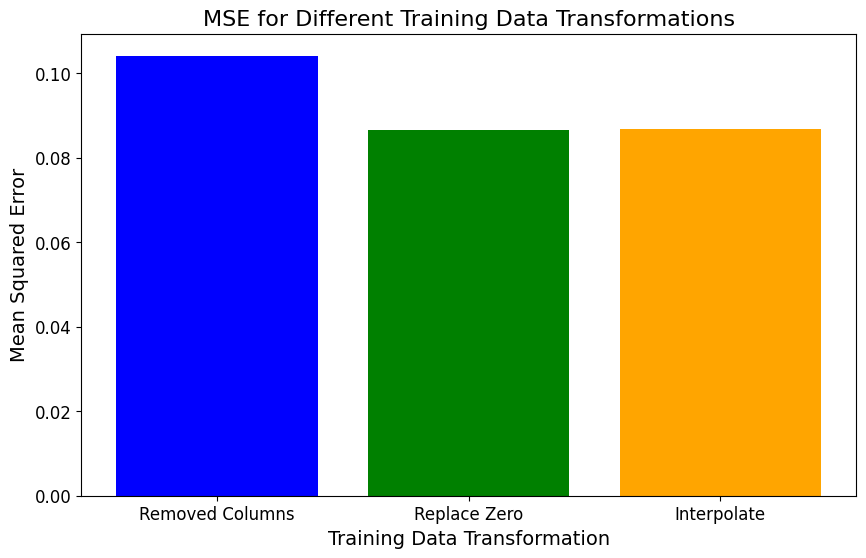

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.metrics import mean_squared_error
import matplotlib.pyplot as plt

training_datasets = {
    'Removed Columns': training_columns_removed,
    'Replace Zero': training_replace_zero,
    'Interpolate': training_interpolate
}


mse_values = []

# Loop through each dataset, train the model, and calculate MSE
for name, X in training_datasets.items():
    X_train, X_val, y_train, y_val = train_test_split(X, Y, test_size=0.1, random_state=42)
    model = LinearRegression()
    model.fit(X_train, y_train)
    y_pred = model.predict(X_val)
    mse = mean_squared_error(y_val, y_pred)
    mse_values.append(mse)

    print("{} - Mean Squared Error:".format(mse) )

# Plotting the MSE values as a bar plot
plt.figure(figsize=(10, 6))
plt.bar(training_datasets.keys(), mse_values, color=['blue', 'green', 'orange'])
plt.xlabel('Training Data Transformation', fontsize=14)
plt.ylabel('Mean Squared Error', fontsize=14)
plt.title('MSE for Different Training Data Transformations', fontsize=16)


plt.xticks(fontsize=12)
plt.yticks(fontsize=12)

plt.show()

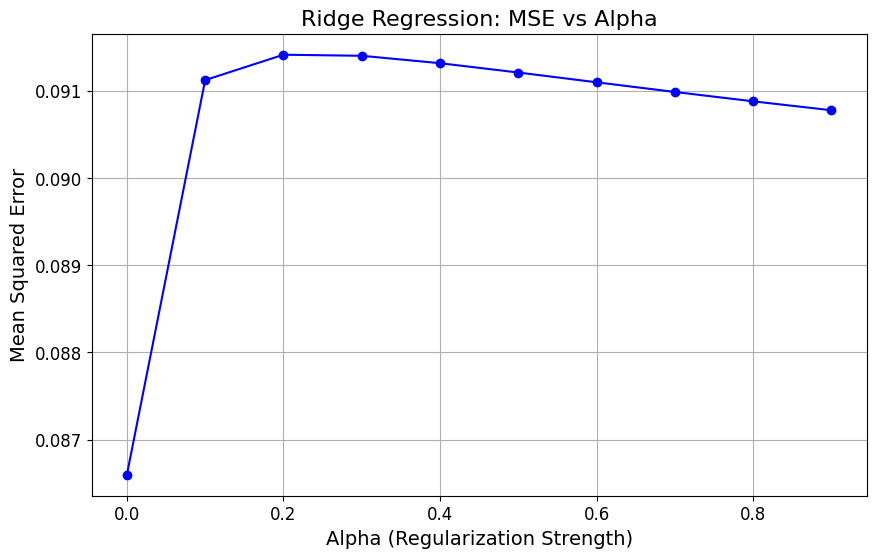

In [ ]:

from sklearn.linear_model import Ridge
import numpy as np

# Split the data
X_train, X_val, y_train, y_val = train_test_split(training_replace_zero, Y, test_size=0.1, random_state=42)

# Range of alpha values
alphas = np.arange(0, 1, 0.1)
mse_values = []

# Train Ridge Regression model for each alpha and store the MSE
for alpha in alphas:
    ridge_model = Ridge(alpha=alpha)
    ridge_model.fit(X_train, y_train)
    y_pred = ridge_model.predict(X_val)
    mse = mean_squared_error(y_val, y_pred)
    mse_values.append(mse)

# Plotting the MSE values for each alpha
plt.figure(figsize=(10, 6))
plt.plot(alphas, mse_values, marker='o', color='b', linestyle='-')
plt.xlabel('Alpha (Regularization Strength)', fontsize=14)
plt.ylabel('Mean Squared Error', fontsize=14)
plt.title('Ridge Regression: MSE vs Alpha', fontsize=16)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.grid(True)
plt.show()


It looks like normal linear regression has slightly better MSE than Ridge. We will use normal linear regression.

In [ ]:
with open('linear_regression_model.pkl', 'wb') as file:
    pickle.dump(model, file)

**Submission Instructions**


- Your submission should include four files, please use your lastname in the place holder.

  - If your last name is Doe then the file for answers will be answers_Doe.txt:
Written answers, the file should be named answers_(lastname).txt
  - The ipynb file, the file should be name P2_(lastname).ipynb
  - The Perceptron model pickle file perceptron_model_(lastname).pkl
  - The Regression model pickle file linear_regression_model_(lastname).pkl

- Please add comments to the code in appropriate places

###Start Early, Good Luck!